In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import torch.nn.functional as F

In [ ]:
# Step 1: Setup Kaggle API and Download Dataset
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d ninamustwin/fer2013
!unzip -q fer2013.zip -d fer2013_data


mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ninamustwin/fer2013
License(s): unknown
 90% 87.0M/96.6M [00:00<00:00, 187MB/s]
100% 96.6M/96.6M [00:00<00:00, 184MB/s]


In [ ]:
import os
import cv2
from PIL import Image
from tqdm import tqdm

# Define paths
csv_path = "./fer2013_data/fer2013.csv"
output_dir = "./fer2013_images"

# Create folders for each class
emotion_labels = {0: "angry", 1: "disgust", 2: "fear", 3: "happy", 4: "sad", 5: "surprise", 6: "neutral"}
for label in emotion_labels.values():
    os.makedirs(os.path.join(output_dir, label), exist_ok=True)

# Read CSV and save images in folders
df = pd.read_csv(csv_path)
for index, row in tqdm(df.iterrows(), total=len(df)):
    pixels = np.array(row["pixels"].split(), dtype=np.uint8).reshape(48, 48)
    image = Image.fromarray(pixels)
    label = emotion_labels[row["emotion"]]
    image.save(f"{output_dir}/{label}/{index}.png")


100%|██████████| 35887/35887 [00:28<00:00, 1242.72it/s]


In [ ]:
# Define Transformations
data_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
dataset = datasets.ImageFolder(root=output_dir, transform=data_transform)

In [ ]:
# Extract class labels dynamically
classes = dataset.classes
print(f"Detected Classes: {classes}")

Detected Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
# Task 2: Train-Validation-Test Split
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - (train_size + val_size)

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

Train size: 21532, Val size: 7177, Test size: 7178


In [ ]:
# Task 3: Visualize 3 images from each class in grayscale
def visualizing_samples(loader, num_samples=3):
    class_counts = {c: 0 for c in classes}
    sample_images = {c: [] for c in classes}

    # Collect required images for each class
    for images, labels in loader:
        for i in range(len(images)):
            label = classes[labels[i].item()]
            if class_counts[label] < num_samples:
                sample_images[label].append(images[i].squeeze(0))  # Remove channel dimension
                class_counts[label] += 1
            if all(count >= num_samples for count in class_counts.values()):
                break
        if all(count >= num_samples for count in class_counts.values()):
            break

    # Plot collected images
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(10, 15))
    for idx, label in enumerate(classes):
        for j in range(num_samples):
            axes[idx, j].imshow(sample_images[label][j], cmap='gray')
            axes[idx, j].set_title(label)
            axes[idx, j].axis("off")
    plt.tight_layout()
    plt.show()



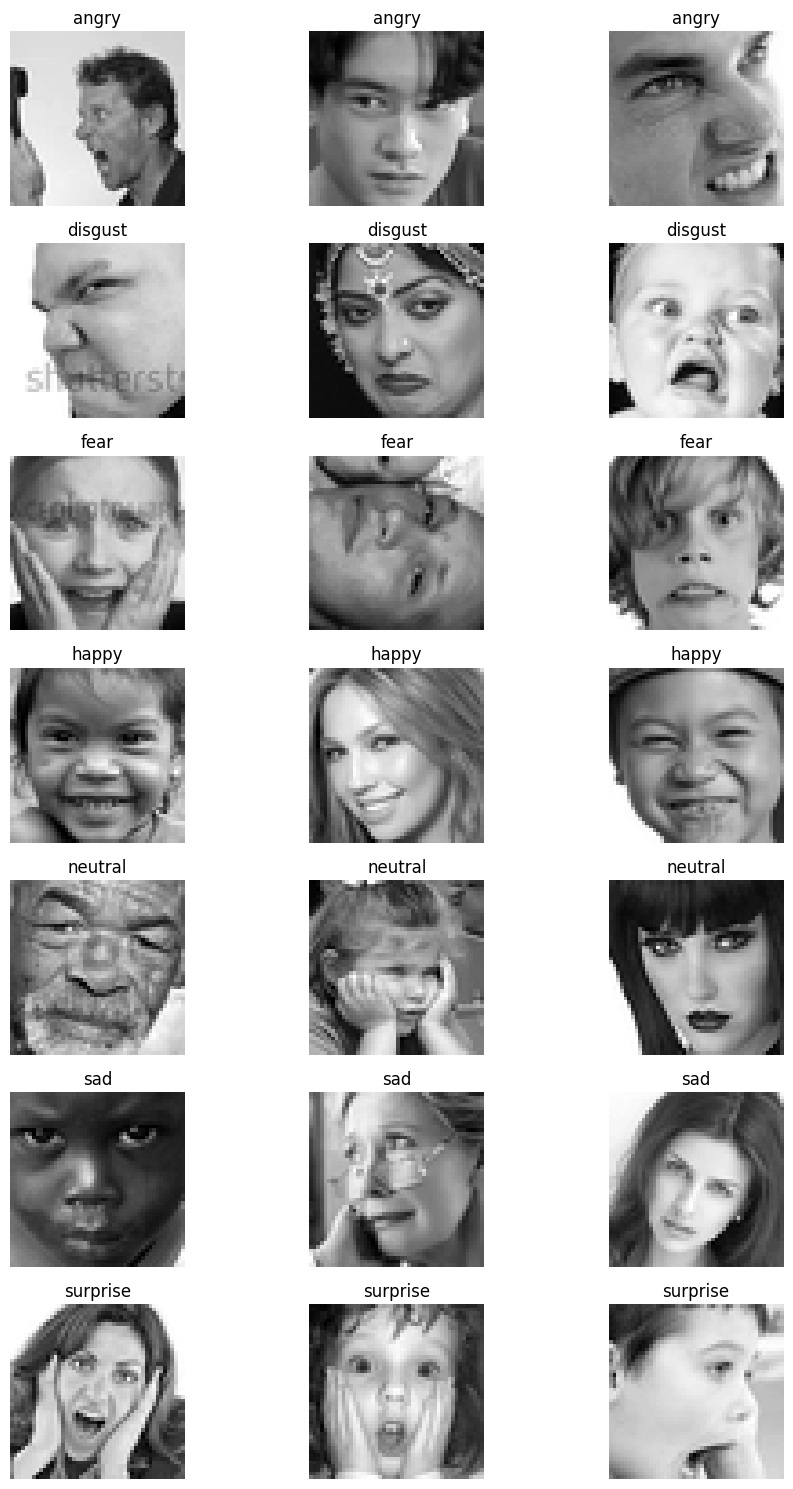

In [ ]:
visualizing_samples(train_loader)

In [ ]:
# Task 4: Define Custom CNN Model
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.residual1 = nn.Conv2d(1, 32, kernel_size=1)  # Residual connection 1
        self.residual2 = nn.Conv2d(32, 64, kernel_size=1)  # Residual connection 2
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling
        self.conv1x1 = nn.Conv2d(64, num_classes, kernel_size=1)  # 1x1 Convolution
        self.relu = nn.ReLU()

    def forward(self, x):
        res1 = self.residual1(x)  # Residual connection 1
        x = self.relu(self.conv1(x) + res1)
        res2 = self.residual2(x)  # Residual connection 2
        x = self.relu(self.conv2(x) + res2)
        x = self.gap(x)
        x = self.conv1x1(x)
        return x.view(x.size(0), -1)  # Fully convolutional output


In [ ]:
# Initialize Model
num_classes = len(classes)
model = CNN(num_classes)

In [ ]:
# Print Model Summary
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (residual1): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1))
  (residual2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=1)
  (conv1x1): Conv2d(64, 7, kernel_size=(1, 1), stride=(1, 1))
  (relu): ReLU()
)


In [ ]:
# Define device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
# Task 5: Train the Model
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
# Ensure inline plotting if using Jupyter Notebook
%matplotlib inline

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15):
    model.to(device)  # Ensure model is on GPU
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to GPU
            labels = labels.long()  # Ensure labels are LongTensor for CrossEntropyLoss

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Compute training accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accuracy = correct / total
        train_accuracies.append(train_accuracy)

        # Validate model
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)  # Move data to GPU
                labels = labels.long()  # Ensure labels are LongTensor

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accuracy = correct_val / total_val
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracy:.4f}")

    # Save model
    torch.save(model.state_dict(), "cnn_model.pth")

    # Define epoch numbers for plotting
    epoch_numbers = list(range(1, epochs + 1))

    # Plot Training & Validation Loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epoch_numbers, train_losses, label="Train Loss", marker='o', linestyle='-')
    plt.plot(epoch_numbers, val_losses, label="Val Loss", marker='s', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.xticks(epoch_numbers)  # Ensure all epochs are displayed on x-axis
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)

    # Plot Training & Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epoch_numbers, train_accuracies, label="Train Acc", marker='o', linestyle='-')
    plt.plot(epoch_numbers, val_accuracies, label="Val Acc", marker='s', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.xticks(epoch_numbers)  # Ensure all epochs are displayed on x-axis
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()  # No need for block=True





Epoch 1/15 - Train Loss: 1.7889, Train Acc: 0.2555, Val Loss: 1.7892, Val Acc: 0.2483
Epoch 2/15 - Train Loss: 1.7784, Train Acc: 0.2602, Val Loss: 1.7803, Val Acc: 0.2572
Epoch 3/15 - Train Loss: 1.7703, Train Acc: 0.2684, Val Loss: 1.7746, Val Acc: 0.2617
Epoch 4/15 - Train Loss: 1.7638, Train Acc: 0.2742, Val Loss: 1.7759, Val Acc: 0.2592
Epoch 5/15 - Train Loss: 1.7581, Train Acc: 0.2781, Val Loss: 1.7646, Val Acc: 0.2711
Epoch 6/15 - Train Loss: 1.7543, Train Acc: 0.2811, Val Loss: 1.7646, Val Acc: 0.2716
Epoch 7/15 - Train Loss: 1.7489, Train Acc: 0.2852, Val Loss: 1.7586, Val Acc: 0.2782
Epoch 8/15 - Train Loss: 1.7441, Train Acc: 0.2892, Val Loss: 1.7525, Val Acc: 0.2808
Epoch 9/15 - Train Loss: 1.7403, Train Acc: 0.2899, Val Loss: 1.7470, Val Acc: 0.2848
Epoch 10/15 - Train Loss: 1.7347, Train Acc: 0.2944, Val Loss: 1.7442, Val Acc: 0.2848
Epoch 11/15 - Train Loss: 1.7290, Train Acc: 0.3003, Val Loss: 1.7504, Val Acc: 0.2845
Epoch 12/15 - Train Loss: 1.7245, Train Acc: 0.3049,

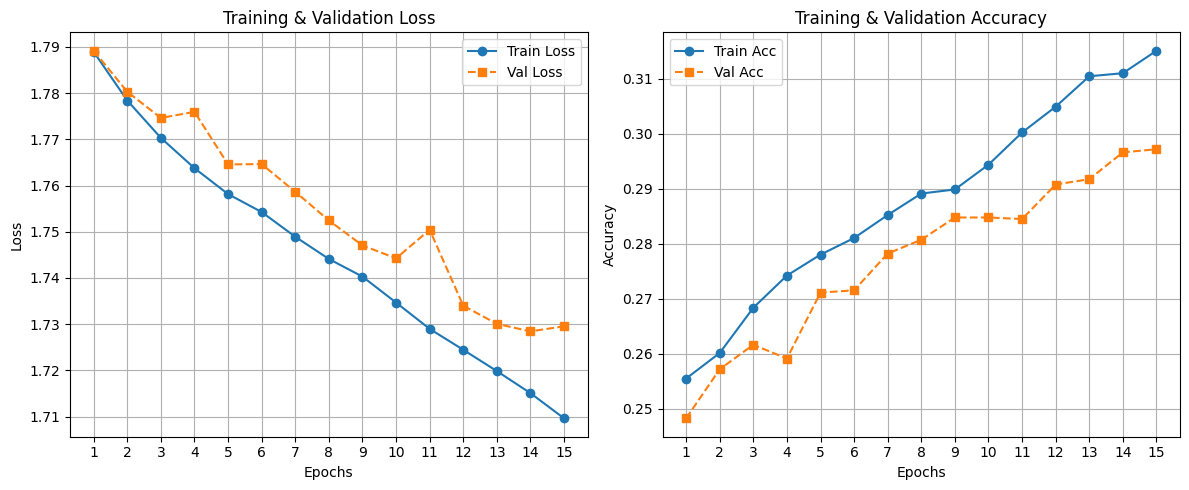

In [ ]:
# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=15)

**Task 6: Evaluation of the model**

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    model.to(device)

    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move images & labels to the same device as the model

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            # Move tensors back to CPU before using NumPy
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

     # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0, labels=np.arange(len(classes)))
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0, labels=np.arange(len(classes)))

    # Print results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Plot confusion matrix with all known labels
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

Accuracy: 0.2994
Precision: 0.2882
Recall: 0.2994


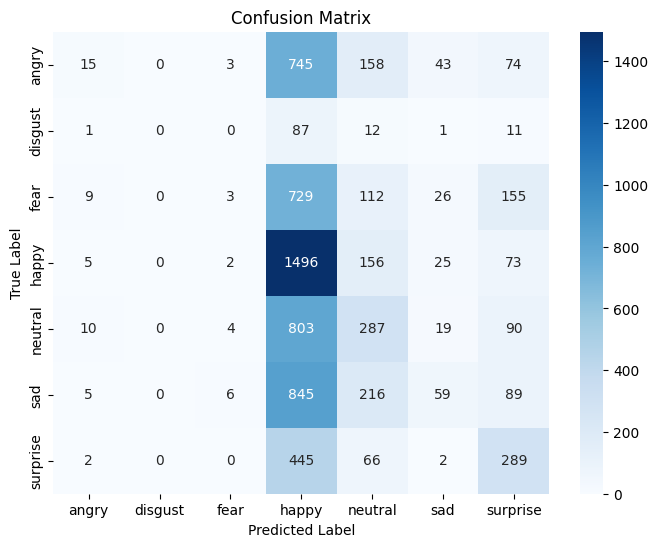

In [ ]:
# Run evaluation on test set
evaluate_model(model, test_loader)

**Task 7:**

In [ ]:
import random

# Hook to extract activations and gradients
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def compute_cam(self):
        # Global Average Pooling on gradients
        pooled_gradients = torch.mean(self.gradients, dim=[2, 3], keepdim=True)

        # Multiply activations with pooled gradients
        cam = torch.mean(pooled_gradients * self.activations, dim=1).squeeze()
        cam = F.relu(cam)  # Apply ReLU to remove negative values

        # Normalize CAM
        cam -= cam.min()
        cam /= cam.max()
        return cam.detach().cpu().numpy()  # FIX: Detach before converting to NumPy

In [ ]:
# Function to visualize Grad-CAM
def visualize_gradcam(model, test_loader):
    model.eval()
    model.to(device)  # Move model to GPU

    gradcam = GradCAM(model, model.conv2)  # Use conv2 as the target layer

    fig, axes = plt.subplots(len(classes), 2, figsize=(8, len(classes) * 2))
    selected_samples = {i: None for i in range(len(classes))}

    # Select one random sample per class
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)  # Move images to GPU
        for i in range(len(images)):
            label = labels[i].item()
            if selected_samples[label] is None:
                selected_samples[label] = images[i]

            if all(v is not None for v in selected_samples.values()):
                break
        if all(v is not None for v in selected_samples.values()):
            break

    # Generate and visualize Grad-CAM for each selected image
    for label, image in selected_samples.items():
        image.requires_grad_()
        output = model(image.unsqueeze(0))  # Forward pass
        target_class = output.argmax(dim=1)  # Predicted class
        model.zero_grad()
        output[0, target_class].backward()  # Backward pass

        gradcam_map = gradcam.compute_cam()

        # Move image to CPU for visualization
        image = image.detach().cpu()  # FIX: Detach before moving to CPU

        # Plot original image
        axes[label, 0].imshow(image.squeeze().numpy(), cmap="gray")
        axes[label, 0].set_title(f"Original ({classes[label]})")
        axes[label, 0].axis("off")

        # Plot Grad-CAM activation map
        axes[label, 1].imshow(image.squeeze().numpy(), cmap="gray")
        axes[label, 1].imshow(gradcam_map, alpha=0.5, cmap="jet")  # Overlay Grad-CAM
        axes[label, 1].set_title(f"Grad-CAM ({classes[label]})")
        axes[label, 1].axis("off")

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


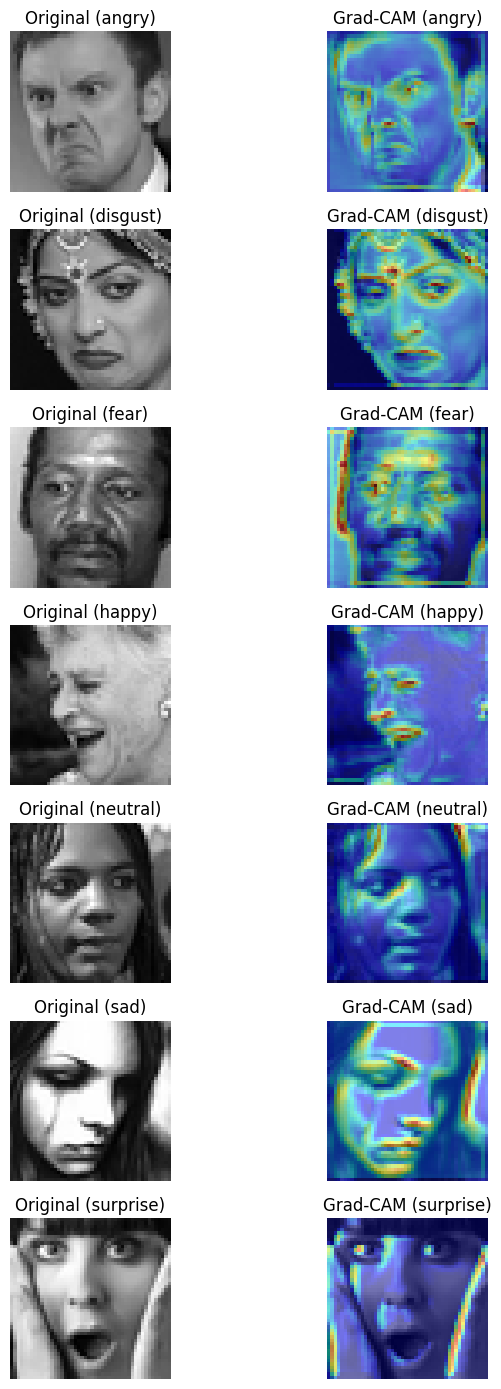

In [ ]:

# Grad-CAM visualization
visualize_gradcam(model, test_loader)


**Task-8**

In [33]:
def execute_adversarial_attack(model, test_loader, perturbation_level=0.1, target_class="happy", original_class="sad"):
    """Applies FGSM attack to modify 'sad' images and compute attack accuracy."""

    model.to(device)
    model.eval()

    initial_correct = 0
    altered_successfully = 0
    total_sad_images = 0

    target_index = classes.index(target_class)
    original_index = classes.index(original_class)

    for batch_data, batch_targets in test_loader:
        batch_data, batch_targets = batch_data.to(device), batch_targets.to(device)

        # Identify only 'Sad' labeled images
        sad_filter = batch_targets == original_index
        if not sad_filter.any():
            continue

        selected_images = batch_data[sad_filter]
        selected_labels = batch_targets[sad_filter]
        total_sad_images += len(selected_images)

        # Ensure gradients are enabled for adversarial modification
        altered_inputs = selected_images.clone().detach().requires_grad_(True)

        # Model evaluation
        model.zero_grad()
        raw_outputs = model(altered_inputs)

        # Determine original classification accuracy
        _, predicted_labels = torch.max(raw_outputs, 1)
        initial_correct += (predicted_labels == selected_labels).sum().item()

        # Compute adversarial gradient
        computed_loss = criterion(raw_outputs, selected_labels)
        computed_loss.backward()

        if altered_inputs.grad is None:
            print("Error: Gradient computation failed. Ensure requires_grad=True before forward propagation.")
            return

        # Modify input images to generate adversarial samples
        perturbation = perturbation_level * altered_inputs.grad.sign()
        adversarial_examples = altered_inputs + perturbation
        adversarial_examples = torch.clamp(adversarial_examples, -1, 1)

        # Re-evaluate model with adversarial inputs
        modified_outputs = model(adversarial_examples)
        _, modified_labels = torch.max(modified_outputs, 1)

        # Count misclassifications as 'Happy'
        altered_successfully += (modified_labels == target_index).sum().item()

    # Output attack accuracy
    if total_sad_images == 0:
        print("No valid 'Sad' images found. Attack accuracy cannot be computed.")
        return

    attack_accuracy = (altered_successfully / total_sad_images) * 100
    print(f"Total 'Sad' instances analyzed: {total_sad_images}")
    print(f"Correctly predicted as 'Sad' before attack: {initial_correct}")
    print(f"Misclassified as 'Happy' after attack: {altered_successfully}")
    print(f"Attack Accuracy: {attack_accuracy:.2f}%")




In [34]:
# Initiate the adversarial attack process
execute_adversarial_attack(model, test_loader, perturbation_level=0.1)

Total 'Sad' instances analyzed: 1220
Correctly predicted as 'Sad' before attack: 59
Misclassified as 'Happy' after attack: 1010
Attack Accuracy: 82.79%
